# Player Matchups EDA

Investigate the player stats data — coverage, quality, and the matchup features built from it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from netball_model.data.database import Database

db = Database('../data/netball.db')
matches = db.get_matches()
matches_df = pd.DataFrame(matches)

# Load all player stats via raw query
with db._connect() as conn:
    rows = conn.execute('SELECT * FROM player_stats').fetchall()
    cols = [d[0] for d in conn.execute('SELECT * FROM player_stats LIMIT 1').description]

stats_df = pd.DataFrame(rows, columns=cols)
print(f'Matches: {len(matches_df)}')
print(f'Player stat rows: {len(stats_df)}')
print(f'Unique players: {stats_df["player_id"].nunique()}')
print(f'Unique matches with stats: {stats_df["match_id"].nunique()}')

Matches: 539
Player stat rows: 11041
Unique players: 254
Unique matches with stats: 539


## Coverage by Season

How many matches have player stats? How many players per match?

In [2]:
# Join season info
stats_with_season = stats_df.merge(
    matches_df[['match_id', 'season', 'date']],
    on='match_id', how='left',
)

# Coverage
match_ids_with_stats = stats_df['match_id'].unique()
matches_df['has_stats'] = matches_df['match_id'].isin(match_ids_with_stats)

coverage = (
    matches_df.groupby('season')
    .agg(total=('match_id', 'count'), with_stats=('has_stats', 'sum'))
    .reset_index()
)
coverage['pct'] = (coverage['with_stats'] / coverage['total'] * 100).round(0)
print(coverage.to_string(index=False))

 season  total  with_stats   pct
   2017     60          60 100.0
   2018     60          60 100.0
   2019     60          60 100.0
   2020     60          60 100.0
   2021     59          59 100.0
   2022     60          60 100.0
   2023     60          60 100.0
   2024     60          60 100.0
   2025     60          60 100.0


## Players per Match

Expect 14 starters (7 per team) plus substitutes. Check for matches with unusual counts.

In [3]:
players_per_match = stats_df.groupby('match_id').size().reset_index(name='n_players')

print(f'Players per match:')
print(players_per_match['n_players'].describe().to_string())
print()

# Starters vs subs
stats_df['is_starter'] = stats_df['position'] != '-'
starters_per_match = (
    stats_df.groupby('match_id')['is_starter']
    .agg(starters='sum', subs=lambda x: (~x).sum())
    .reset_index()
)

print('Starters per match:')
print(starters_per_match['starters'].describe().to_string())
print()
print('Subs per match:')
print(starters_per_match['subs'].describe().to_string())

# Flag unusual matches
unusual = starters_per_match[starters_per_match['starters'] != 14]
if not unusual.empty:
    print(f'\nMatches with != 14 starters: {len(unusual)}')
    print(unusual.head(10).to_string(index=False))
else:
    print('\nAll matches have exactly 14 starters.')

Players per match:
count    539.000000
mean      20.484230
std        1.283739
min       20.000000
25%       20.000000
50%       20.000000
75%       20.000000
max       24.000000

Starters per match:
count    539.0
mean      14.0
std        0.0
min       14.0
25%       14.0
50%       14.0
75%       14.0
max       14.0

Subs per match:
count    539.000000
mean       6.484230
std        1.283739
min        6.000000
25%        6.000000
50%        6.000000
75%        6.000000
max       10.000000

All matches have exactly 14 starters.


## Position Distribution

Verify all 7 positions are represented and check for unexpected position codes.

In [4]:
print('Position counts (all records):')
print(stats_df['position'].value_counts().to_string())
print()

# Starters only
starters = stats_df[stats_df['is_starter']].copy()
print('Position counts (starters only):')
print(starters['position'].value_counts().to_string())

# Check each match has all 7 positions per team
expected_positions = {'GS', 'GA', 'WA', 'C', 'WD', 'GD', 'GK'}
missing_pos_matches = []
for (mid, team), grp in starters.groupby(['match_id', 'team']):
    positions = set(grp['position'])
    missing = expected_positions - positions
    if missing:
        missing_pos_matches.append({'match_id': mid, 'team': team, 'missing': missing})

if missing_pos_matches:
    print(f'\nMatches with missing positions: {len(missing_pos_matches)}')
    print(pd.DataFrame(missing_pos_matches).head(10).to_string(index=False))
else:
    print('\nAll teams have all 7 starting positions in every match.')

Position counts (all records):
position
-     3495
GS    1078
GA    1078
WA    1078
C     1078
WD    1078
GD    1078
GK    1078

Position counts (starters only):
position
GS    1078
GA    1078
WA    1078
C     1078
WD    1078
GD    1078
GK    1078

All teams have all 7 starting positions in every match.


## Stat Distributions

Overview of the per-player stat columns. Look for zeros, outliers, and suspicious patterns.

In [5]:
stat_cols = ['goals', 'attempts', 'assists', 'rebounds', 'feeds',
             'turnovers', 'gains', 'intercepts', 'deflections',
             'penalties', 'centre_pass_receives', 'net_points']

print('Stat summary (starters only):')
print(starters[stat_cols].describe().T.to_string(float_format='{:.1f}'.format))

Stat summary (starters only):
                      count  mean  std   min  25%  50%  75%   max
goals                7546.0   7.5 14.4   0.0  0.0  0.0  9.0  75.0
attempts             7546.0   8.7 16.1   0.0  0.0  0.0 12.0  76.0
assists              7546.0   6.3  7.9   0.0  0.0  2.0 12.0  40.0
rebounds             7546.0   0.8  1.5   0.0  0.0  0.0  1.0  13.0
feeds                7546.0  10.8 13.1   0.0  0.0  4.0 20.8  66.0
turnovers            7546.0   2.4  2.0   0.0  1.0  2.0  4.0  11.0
gains                7546.0   1.6  2.2   0.0  0.0  1.0  2.0  15.0
intercepts           7546.0   0.8  1.2   0.0  0.0  0.0  1.0   9.0
deflections          7546.0   2.0  2.3   0.0  0.0  1.0  3.0  15.0
penalties            7546.0   7.3  5.5   0.0  3.0  6.0 11.0  40.0
centre_pass_receives 7546.0   6.8  8.3   0.0  0.0  3.0 11.0  42.0
net_points           7546.0  42.0 33.6 -50.0 14.0 39.0 65.4 165.0


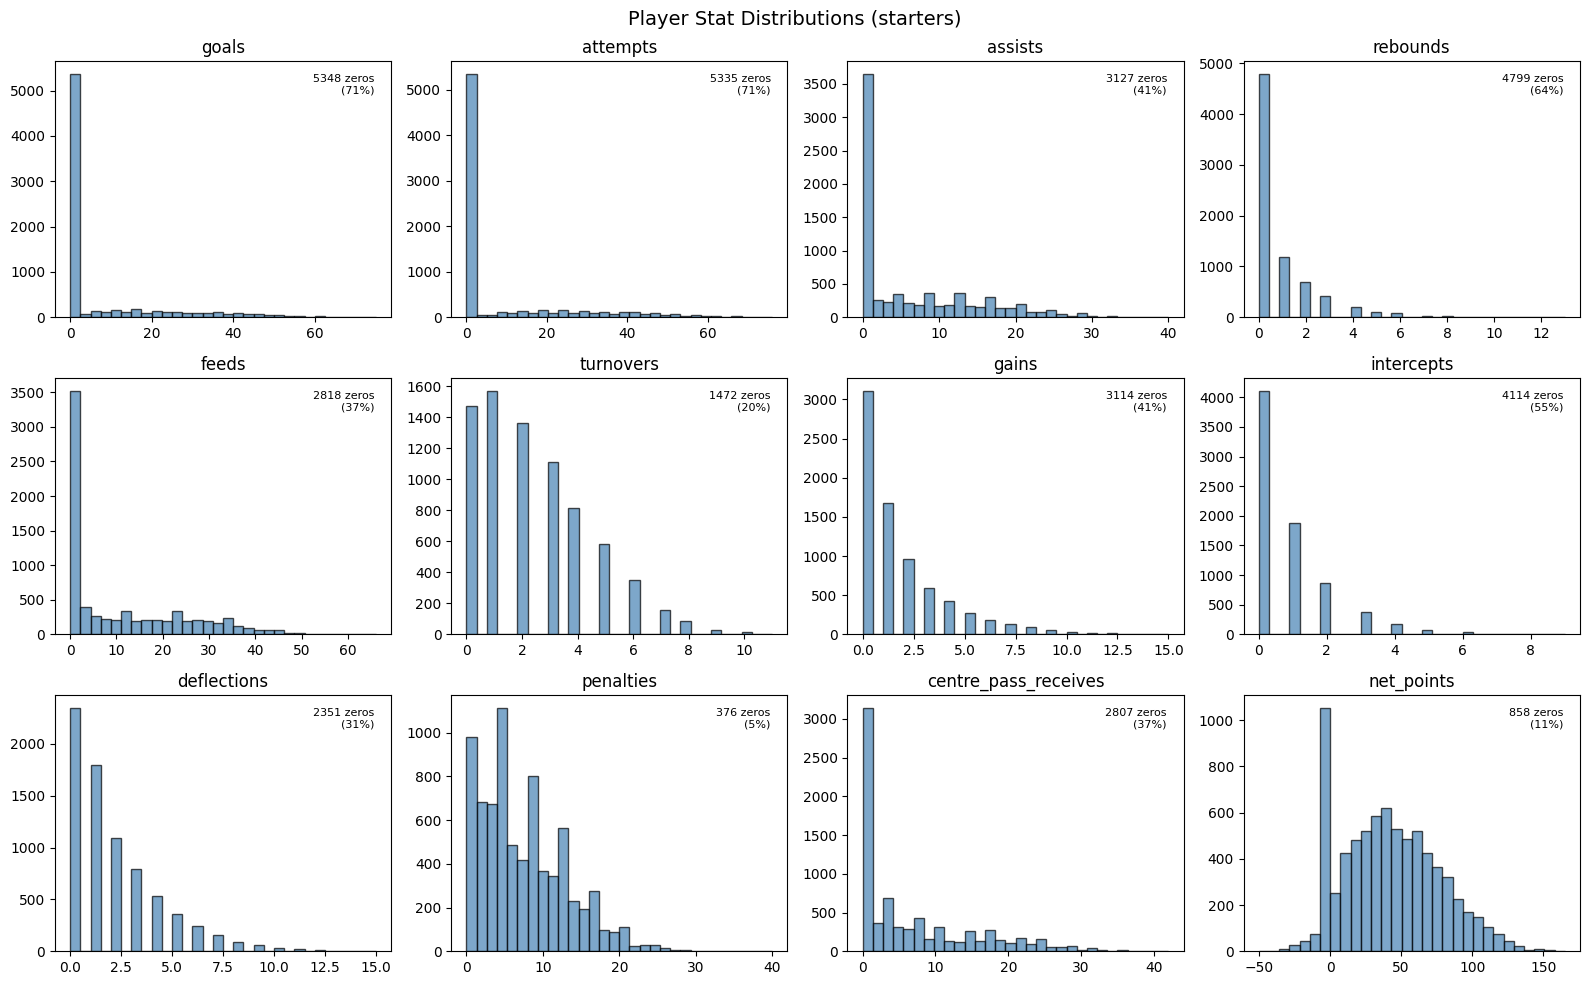

In [6]:
# Distribution plots
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(stat_cols):
    ax = axes[i]
    data = starters[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
    zeros = (data == 0).sum()
    ax.text(0.95, 0.95, f'{zeros} zeros\n({zeros/len(data):.0%})',
            transform=ax.transAxes, ha='right', va='top', fontsize=8)

plt.suptitle('Player Stat Distributions (starters)', fontsize=14)
plt.tight_layout()
plt.show()

## Stats by Position

Shooters (GS/GA) should dominate goals/attempts. Defenders (GD/GK) should lead in gains/intercepts.

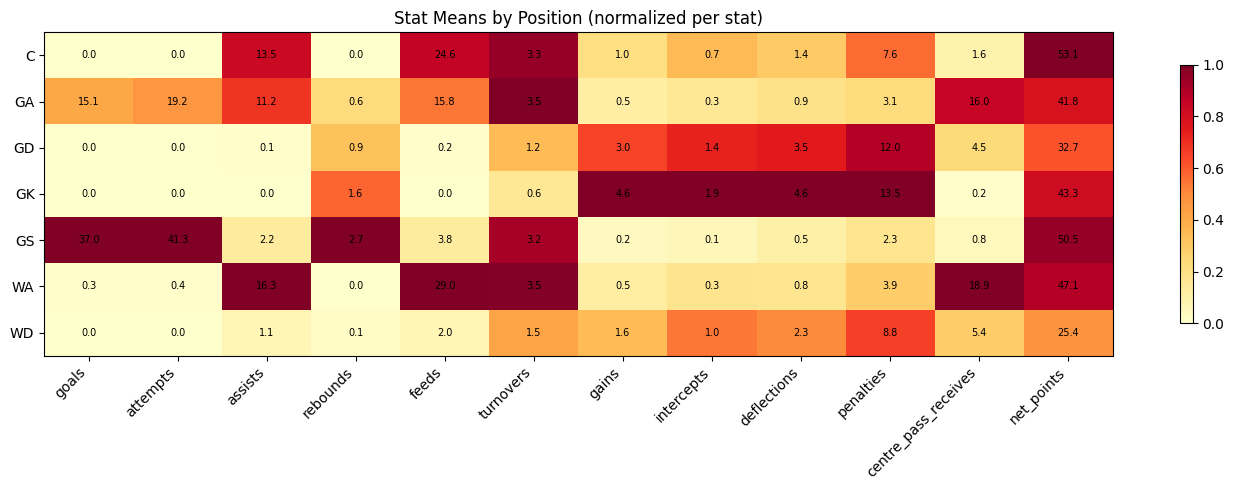

In [7]:
pos_means = starters.groupby('position')[stat_cols].mean()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
# Normalize per column for visibility
normed = pos_means.div(pos_means.max())
im = ax.imshow(normed.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(stat_cols)))
ax.set_xticklabels(stat_cols, rotation=45, ha='right')
ax.set_yticks(range(len(pos_means)))
ax.set_yticklabels(pos_means.index)
ax.set_title('Stat Means by Position (normalized per stat)')

# Annotate with raw values
for i in range(len(pos_means)):
    for j in range(len(stat_cols)):
        ax.text(j, i, f'{pos_means.values[i, j]:.1f}',
                ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Shooting Data Quality

Goals and attempts should only be non-zero for shooters (GS, GA). Non-shooters with goals would indicate data issues.

In [8]:
shooters = starters[starters['position'].isin(['GS', 'GA'])]
non_shooters = starters[~starters['position'].isin(['GS', 'GA'])]

print('Shooters (GS, GA):')
print(f'  Total: {len(shooters)}')
print(f'  goals > 0: {(shooters["goals"] > 0).sum()} ({(shooters["goals"] > 0).mean():.0%})')
print(f'  attempts > 0: {(shooters["attempts"] > 0).sum()} ({(shooters["attempts"] > 0).mean():.0%})')
print(f'  avg goals: {shooters["goals"].mean():.1f}')
print(f'  avg attempts: {shooters["attempts"].mean():.1f}')
print(f'  avg shooting%: {(shooters["goals"] / shooters["attempts"].replace(0, np.nan)).mean():.1%}')
print()
print('Non-shooters (WA, C, WD, GD, GK):')
print(f'  Total: {len(non_shooters)}')
print(f'  goals > 0: {(non_shooters["goals"] > 0).sum()}')
print(f'  attempts > 0: {(non_shooters["attempts"] > 0).sum()}')

if (non_shooters['goals'] > 0).any():
    print('\n  WARNING: Non-shooters with goals detected:')
    bad = non_shooters[non_shooters['goals'] > 0]
    print(bad[['match_id', 'player_name', 'team', 'position', 'goals', 'attempts']].to_string(index=False))

Shooters (GS, GA):
  Total: 2156
  goals > 0: 2148 (100%)
  attempts > 0: 2155 (100%)
  avg goals: 26.0
  avg attempts: 30.3
  avg shooting%: 82.3%

Non-shooters (WA, C, WD, GD, GK):
  Total: 5390
  goals > 0: 50
  attempts > 0: 56

   match_id player_name                  team position  goals  attempts
10083_05_04             Adelaide Thunderbirds       WA      3         5
10083_06_03             Adelaide Thunderbirds       WA      9        12
10084_03_01                    GIANTS Netball       WA      4         7
10724_13_01                        NSW Swifts       WA      9        10
11108_01_03                    GIANTS Netball       WA      3         4
11108_02_01                    GIANTS Netball       WA     11        23
11108_04_02                    GIANTS Netball       WA     12        14
11108_08_02                    GIANTS Netball       WA     25        33
11108_12_04             Adelaide Thunderbirds       WA      5        11
11108_13_03             Adelaide Thunderbirds  

## Matchup Feature Preview

Compute the position-pair matchup features for a few sample matches to verify they look reasonable.

In [ ]:
from netball_model.features.player_profile import PlayerProfiler
from netball_model.features.matchups import MatchupFeatures

profiler = PlayerProfiler()
matchups = MatchupFeatures()

# Pick 5 recent matches that have player stats
recent = (
    matches_df[matches_df['has_stats']]
    .sort_values('date', ascending=False)
    .head(5)
)

for _, m in recent.iterrows():
    mid = m['match_id']
    home = m['home_team']
    away = m['away_team']

    match_starters = starters[starters['match_id'] == mid]
    if match_starters.empty:
        continue

    home_profiles = {}
    away_profiles = {}

    for _, s in match_starters.iterrows():
        pos = s['position']
        pid = s['player_id']
        team = s['team']

        # Get last 5 matches for this player before this match
        history = db.get_player_history(pid, m['date'], limit=5)
        profile = profiler.compute_profile(history, pos)

        if profile is None:
            continue

        if team == home:
            home_profiles[pos] = profile
        elif team == away:
            away_profiles[pos] = profile

    feats = matchups.compute_features(home_profiles, away_profiles)

    print(f'\n{m["date"]} | {home} vs {away}')
    for k, v in sorted(feats.items()):
        print(f'  {k}: {v:+.3f}')

## Matchup Feature Distributions

Compute matchup features across all matches to check distributions and look for anomalies.

In [ ]:
from netball_model.features.builder import FeatureBuilder

# Load player stats for all matches
player_stats = {}
for m in matches:
    s = db.get_starters_for_match(m['match_id'])
    if s:
        player_stats[m['match_id']] = s

print(f'Matches with player stats loaded: {len(player_stats)}')

# Build features for matches that have stats (start_index=5 to ensure history)
builder = FeatureBuilder(matches, player_stats=player_stats)
rows = []
for i in range(5, len(matches)):
    row = builder.build_row(i)
    rows.append(row)

feat_df = pd.DataFrame(rows)

# Get matchup columns (interaction features + composites)
matchup_cols = [c for c in feat_df.columns if '_vs_' in c or c.endswith('_matchup')]
print(f'Matchup feature columns ({len(matchup_cols)}): {matchup_cols}')
print(f'Rows with matchup data: {feat_df[matchup_cols[0]].notna().sum() if matchup_cols else 0}')

In [ ]:
if matchup_cols:
    print('Matchup feature summary:')
    print(feat_df[matchup_cols].describe().T.to_string(float_format='{:.3f}'.format))
    print()

    n = len(matchup_cols)
    ncols = 4
    nrows = -(-n // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(matchup_cols):
        data = feat_df[col].dropna()
        axes[i].hist(data, bins=25, color='darkorange', edgecolor='black', alpha=0.7)
        axes[i].axvline(0, color='grey', ls='--', lw=0.8)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('Home - Away')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Matchup Feature Distributions', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No matchup features found — check player stats coverage.')

## Matchup Features vs Margin

Do matchup features correlate with match margin? A positive correlation would suggest they carry signal.

In [ ]:
if matchup_cols:
    print('Correlation with margin:')
    for col in matchup_cols:
        valid = feat_df[[col, 'margin']].dropna()
        if len(valid) > 10:
            corr = valid[col].corr(valid['margin'])
            print(f'  {col}: {corr:+.3f} (n={len(valid)})')

    # Scatter plots in grid
    n = len(matchup_cols)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(matchup_cols):
        valid = feat_df[[col, 'margin']].dropna()
        axes[i].scatter(valid[col], valid['margin'], alpha=0.3, s=10)
        axes[i].axhline(0, color='grey', ls='--', lw=0.5)
        axes[i].axvline(0, color='grey', ls='--', lw=0.5)
        axes[i].set_xlabel(col, fontsize=8)
        axes[i].set_ylabel('Margin')
        if len(valid) > 10:
            z = np.polyfit(valid[col], valid['margin'], 1)
            x_line = np.linspace(valid[col].min(), valid[col].max(), 50)
            axes[i].plot(x_line, np.polyval(z, x_line), 'r-', lw=1)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Matchup Features vs Match Margin', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No matchup features to correlate.')

## Checklist

| Check | What to look for |
|-------|-----------------|
| Coverage | Every match should have 14 starters (7 per team) |
| Positions | All 7 positions present for each team in each match |
| Shooting | Only GS/GA should have goals/attempts > 0 |
| Stat ranges | No negative values, no implausible outliers |
| Matchup features | Distributions centred near 0, mild correlation with margin expected |